# Resampling Techniques Lab
## Problem 1: Empirical Bias Expansion and Problem 2: CLT Behavior

In [6]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, ks_2samp, wasserstein_distance
from sklearn.linear_model import LinearRegression

np.random.seed(42)


## Problem 1: Empirical Bias Expansion


Bias Table (λ = 1)


,n,Bias
0,5,0.25436
1,10,0.10829
2,20,0.05222
3,50,0.01991
4,100,0.01102


Regression: Bias ≈ 0.9288/n + 1.7074/n²


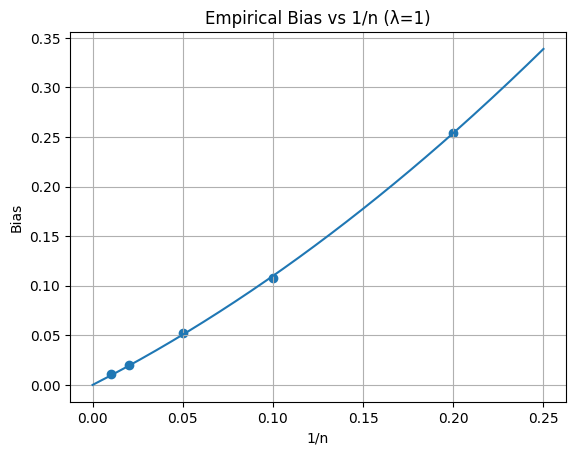


Bias Table (λ = 3)


,n,Bias
0,5,0.77226
1,10,0.33259
2,20,0.15382
3,50,0.06397
4,100,0.02769


Regression: Bias ≈ 2.8231/n + 5.1824/n²


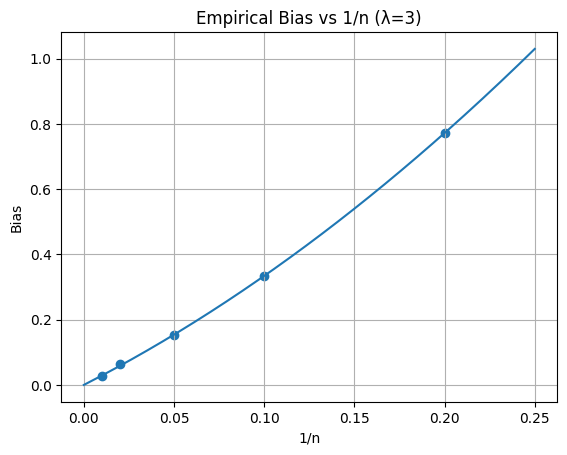


Bias Table (λ = 5)


,n,Bias
0,5,1.16275
1,10,0.53072
2,20,0.27757
3,50,0.11130
4,100,0.05124


Regression: Bias ≈ 5.0863/n + 3.5762/n²


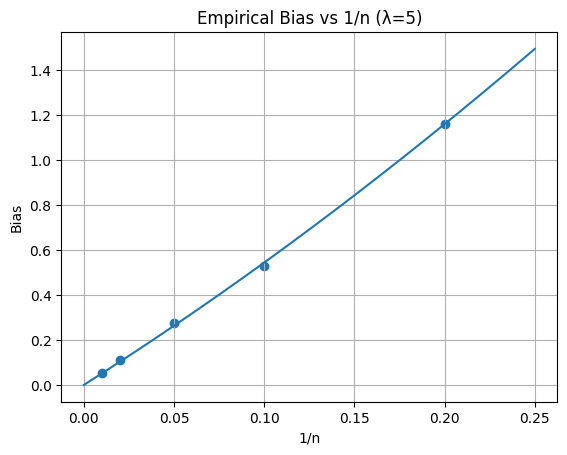


Bias Table (λ = 7)


,n,Bias
0,5,1.73805
1,10,0.76207
2,20,0.35979
3,50,0.15937
4,100,0.06894


Regression: Bias ≈ 6.7102/n + 9.8581/n²


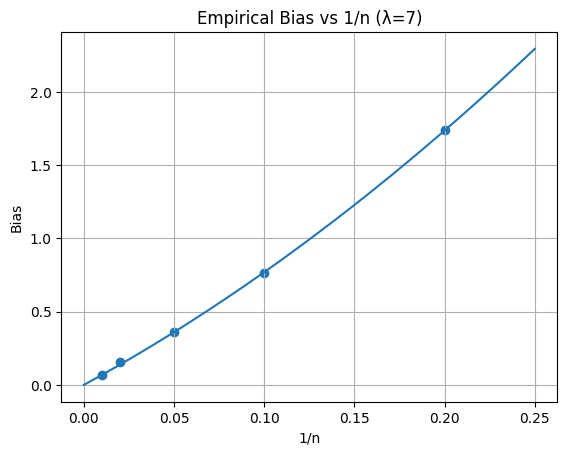

In [7]:

M = 10000
n_values = np.array([5, 10, 20, 50, 100])
lambdas = [1, 3, 5, 7]

for lam in lambdas:
    biases = []

    for n in n_values:
        X = np.random.exponential(scale=1/lam, size=(M, n))
        lam_hat = 1 / X.mean(axis=1)
        bias = lam_hat.mean() - lam
        biases.append(bias)

    df = pd.DataFrame({"n": n_values, "Bias": biases})
    print(f"\nBias Table (λ = {lam})")
    display(df.round(5))

    Xreg = np.column_stack([1/n_values, 1/n_values**2])
    model = LinearRegression(fit_intercept=False).fit(Xreg, biases)
    c1, c2 = model.coef_
    print(f"Regression: Bias ≈ {c1:.4f}/n + {c2:.4f}/n²")

    plt.figure()
    plt.scatter(1/n_values, biases)
    x = np.linspace(0, 0.25, 200)
    plt.plot(x, c1*x + c2*x**2)
    plt.xlabel("1/n")
    plt.ylabel("Bias")
    plt.title(f"Empirical Bias vs 1/n (λ={lam})")
    plt.grid(True)
    plt.show()


## Problem 2: CLT Behavior

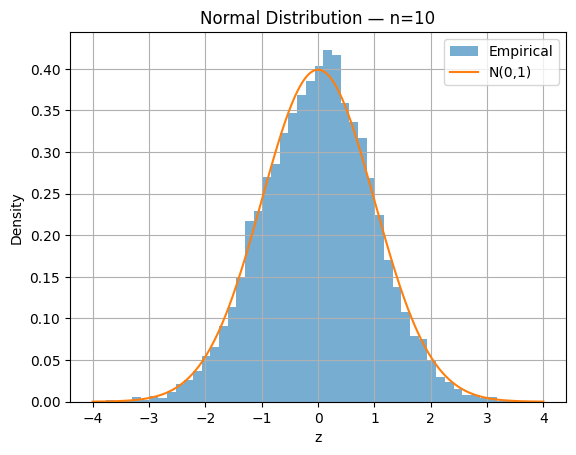

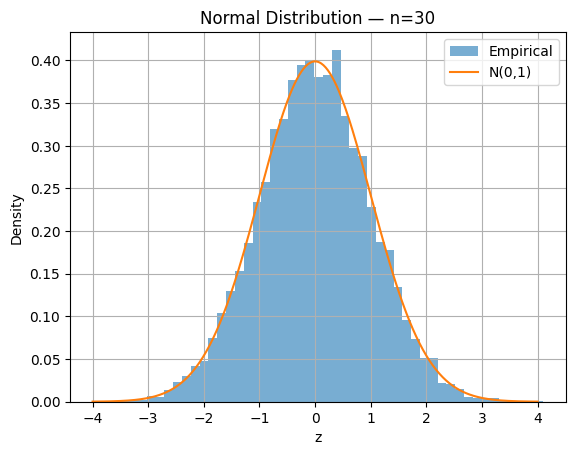

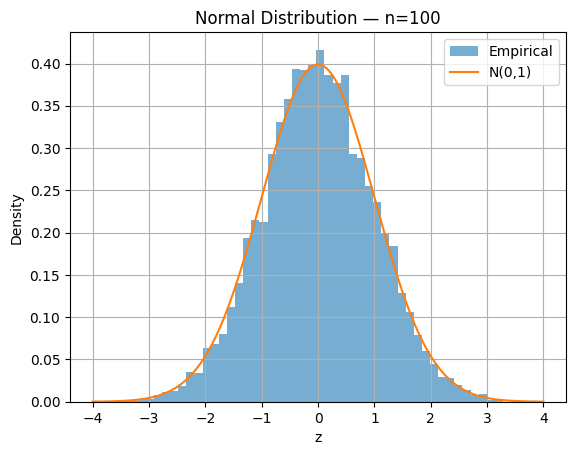


Distance Table (Normal)


,n,KS Distance,Wasserstein Distance
0,10,0.0171,0.0314
1,30,0.0106,0.0210
2,100,0.0143,0.0254


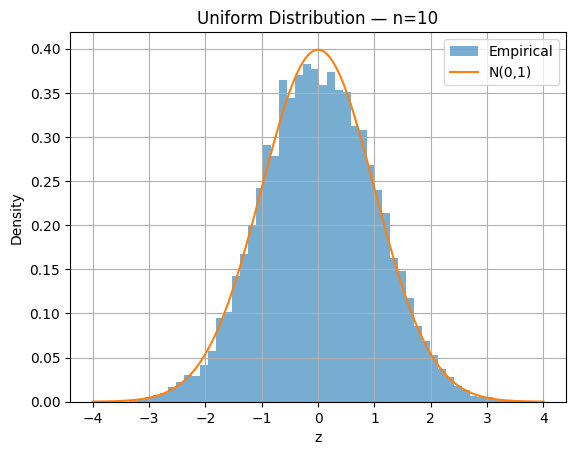

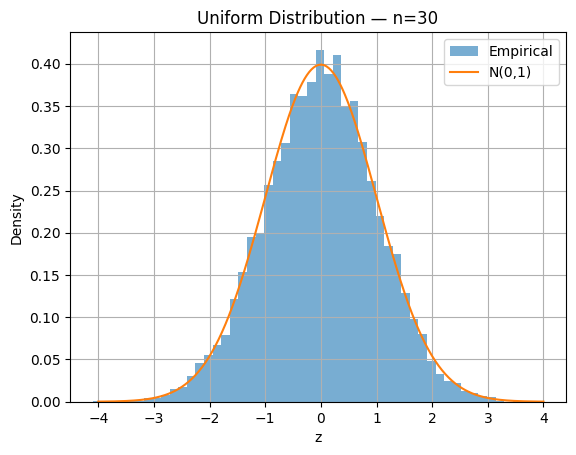

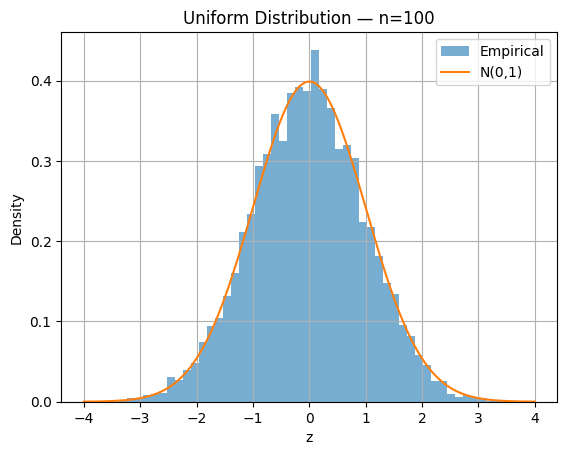


Distance Table (Uniform)


,n,KS Distance,Wasserstein Distance
0,10,0.0136,0.0221
1,30,0.0072,0.0107
2,100,0.0119,0.0140


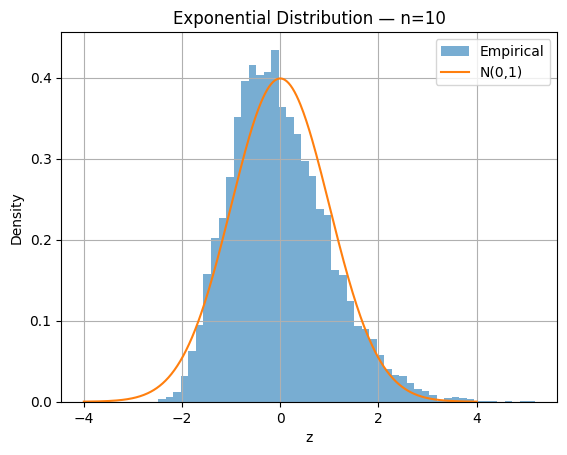

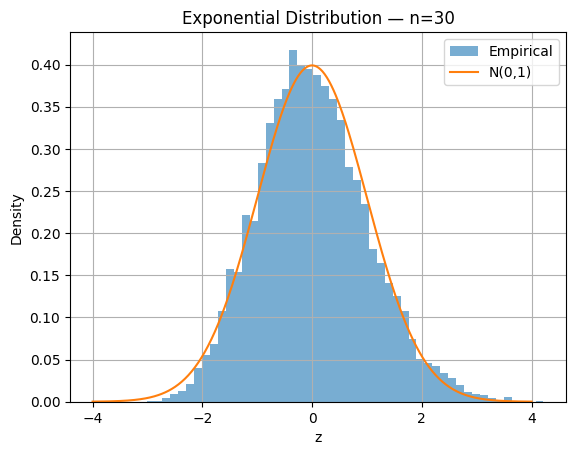

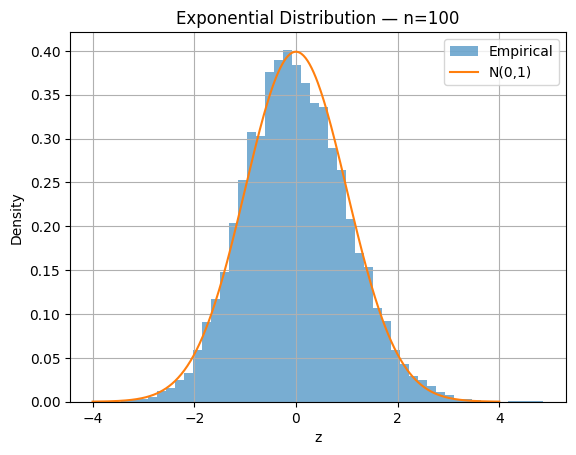


Distance Table (Exponential)


,n,KS Distance,Wasserstein Distance
0,10,0.0423,0.1006
1,30,0.0224,0.0511
2,100,0.0156,0.0290


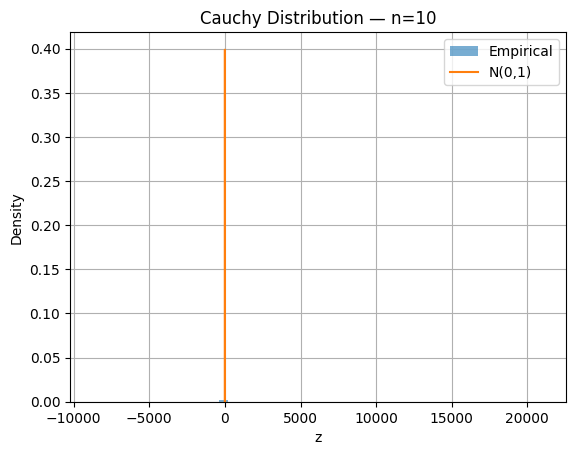

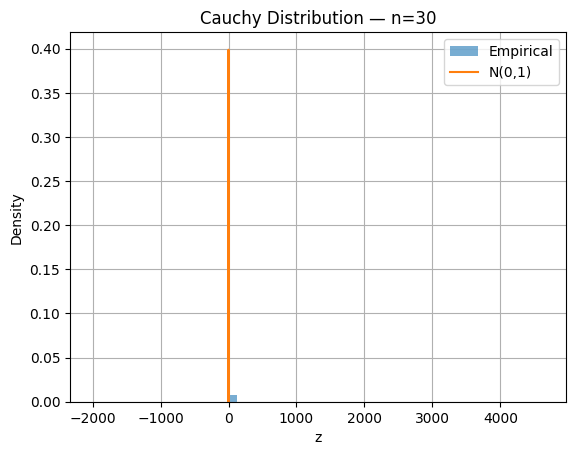

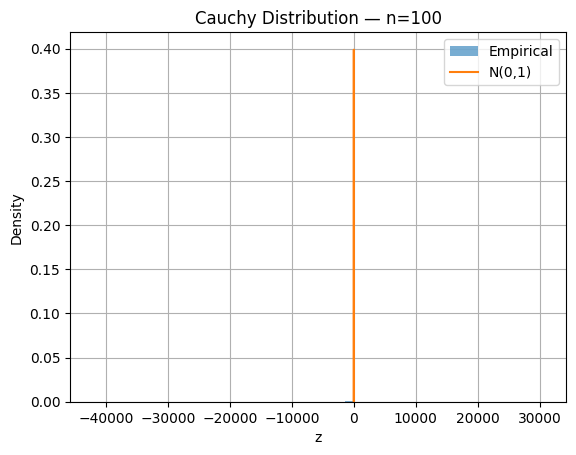


Distance Table (Cauchy)


,n,KS Distance,Wasserstein Distance
0,10,0.1285,6.9877
1,30,0.1296,4.8497
2,100,0.1336,11.5544


In [8]:

M = 10000
n_vals = [10, 30, 100]

distributions = {
    "Normal": (lambda s: np.random.normal(0,1,s), 0, 1),
    "Uniform": (lambda s: np.random.uniform(0,1,s), 0.5, 1/12),
    "Exponential": (lambda s: np.random.exponential(1,s), 1, 1),
    "Cauchy": (lambda s: np.random.standard_cauchy(s), None, None)
}

for name, (sampler, mu, var) in distributions.items():
    rows = []

    for n in n_vals:
        X = sampler((M, n))
        Xbar = X.mean(axis=1)

        if var is not None:
            Zn = (Xbar - mu) / np.sqrt(var/n)
        else:
            Zn = Xbar

        Zref = np.random.normal(0,1,M)
        ks = ks_2samp(Zn, Zref).statistic
        w = wasserstein_distance(Zn, Zref)

        rows.append([n, ks, w])

        plt.figure()
        plt.hist(Zn, bins=50, density=True, alpha=0.6, label="Empirical")
        x = np.linspace(-4,4,400)
        plt.plot(x, norm.pdf(x), label="N(0,1)")
        plt.title(f"{name} Distribution — n={n}")
        plt.xlabel("z")
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True)
        plt.show()

    df_dist = pd.DataFrame(rows, columns=["n", "KS Distance", "Wasserstein Distance"])
    print(f"\nDistance Table ({name})")
    display(df_dist.round(4))
